<a href="https://colab.research.google.com/github/mohamed7saad7/FIFA21-Market-Value-Predictor/blob/main/project-fifa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import  mean_squared_error , r2_score , mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import tensorflow as tf
from tensorflow.keras import layers, models



1- Load the dataset

In [ ]:
df=pd.read_csv('/content/players_21.csv')
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club_name,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,33,6/24/1987,170,72,Argentina,FC Barcelona,...,66+3,65+3,65+3,65+3,66+3,62+3,52+3,52+3,52+3,62+3
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,35,2/5/1985,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,54+3,54+3,54+3,61+3
2,200389,https://sofifa.com/player/200389/jan-oblak/210002,J. Oblak,Jan Oblak,27,1/7/1993,188,87,Slovenia,Atlético Madrid,...,32+3,36+3,36+3,36+3,32+3,32+3,33+3,33+3,33+3,32+3
3,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,31,8/21/1988,184,80,Poland,FC Bayern München,...,64+3,65+3,65+3,65+3,64+3,61+3,60+3,60+3,60+3,61+3
4,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,28,2/5/1992,175,68,Brazil,Paris Saint-Germain,...,67+3,62+3,62+3,62+3,67+3,62+3,49+3,49+3,49+3,62+3


2-Data exploration

In [ ]:
df.shape

(18944, 106)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18944 entries, 0 to 18943
Columns: 106 entries, sofifa_id to rb
dtypes: float64(18), int64(44), object(44)
memory usage: 15.3+ MB


In [ ]:
df.describe()

,sofifa_id,age,height_cm,weight_kg,league_rank,overall,potential,value_eur,wage_eur,international_reputation,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,18944.000000,18944.000000,18944.000000,18944.000000,18719.000000,18944.000000,18944.000000,1.894400e+04,18944.000000,18944.000000,...,18944.000000,18944.000000,0.0,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000
mean,226242.402872,25.225823,181.190773,75.016892,1.357070,65.677787,71.086729,2.224813e+06,8675.852513,1.091850,...,48.050412,57.978674,NaN,47.581767,45.546505,16.446052,16.236486,16.103357,16.225982,16.551309
std,27171.091056,4.697354,6.825672,7.057140,0.739327,7.002278,6.109985,5.102486e+06,19654.774894,0.361841,...,15.671721,12.118390,NaN,21.402461,20.953997,17.577332,16.845480,16.519399,17.017341,17.878121
min,41.000000,16.000000,155.000000,50.000000,1.000000,47.000000,47.000000,0.000000e+00,0.000000,1.000000,...,6.000000,12.000000,NaN,5.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,210030.500000,21.000000,176.000000,70.000000,1.000000,61.000000,67.000000,3.000000e+05,1000.000000,1.000000,...,38.750000,50.000000,NaN,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,232314.500000,25.000000,181.000000,75.000000,1.000000,66.000000,71.000000,6.500000e+05,3000.000000,1.000000,...,49.000000,59.000000,NaN,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,246760.250000,29.000000,186.000000,80.000000,1.000000,70.000000,75.000000,1.800000e+06,7000.000000,1.000000,...,60.000000,66.000000,NaN,65.000000,63.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,258970.000000,53.000000,206.000000,110.000000,4.000000,93.000000,95.000000,1.055000e+08,560000.000000,5.000000,...,92.000000,96.000000,NaN,93.000000,90.000000,90.000000,92.000000,93.000000,91.000000,90.000000


In [ ]:

missing_values = df.isnull().sum()
print(f"Total missing values: {missing_values.sum()}")
print('-----------------------------------------------------')
# "The dataset contains 106 features, ranging from player skills, personal info,
# to financial values. This requires careful feature selection and cleaning.
missing_cols = missing_values[missing_values > 0]
print(missing_cols)

Total missing values: 217921
-----------------------------------------------------
club_name                 225
league_name               225
league_rank               225
release_clause_eur        995
player_tags             17536
team_position             225
team_jersey_number        225
loaned_from             18186
joined                    983
contract_valid_until      225
nation_position         17817
nation_jersey_number    17817
pace                     2083
shooting                 2083
passing                  2083
dribbling                2083
defending                2083
physic                   2083
gk_diving               16861
gk_handling             16861
gk_kicking              16861
gk_reflexes             16861
gk_speed                16861
gk_positioning          16861
player_traits           10629
defending_marking       18944
dtype: int64


 Keep only important columns


In [ ]:
cols=['short_name','age','nationality','club_name',
        'overall','potential','value_eur','wage_eur',
        'pace','shooting','passing','dribbling','defending','physic']
df = df[cols]


In [ ]:
df.isnull().sum()

,0
short_name,0
age,0
nationality,0
club_name,225
overall,0
potential,0
value_eur,0
wage_eur,0
pace,2083
shooting,2083


Drop missing values (clean the dataset)

In [ ]:
df = df.dropna()

After data cleaning, the dataset is focused on outfield players to ensure a fair comparison of physical and technical attributes

In [ ]:
df.sample()

,short_name,age,nationality,club_name,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic
8601,L. Adžić,21,Serbia,MKE Ankaragücü,66,75,1000000,6000,74.0,63.0,63.0,69.0,33.0,59.0


In [ ]:
#  Basic KPIs
print("Average Age:", df['age'].mean().round(2))



Average Age: 25.05


In [ ]:
# Top 10 players by Overall rating
print("\nTop 10 Players by Overall:\n")
df[['short_name','overall','potential','club_name','nationality']].sort_values('overall',ascending=False).head(10)



Top 10 Players by Overall:



,short_name,overall,potential,club_name,nationality
0,L. Messi,93,93,FC Barcelona,Argentina
1,Cristiano Ronaldo,92,92,Juventus,Portugal
3,R. Lewandowski,91,91,FC Bayern München,Poland
5,K. De Bruyne,91,91,Manchester City,Belgium
4,Neymar Jr,91,91,Paris Saint-Germain,Brazil
8,V. van Dijk,90,91,Liverpool,Netherlands
6,K. Mbappé,90,95,Paris Saint-Germain,France
11,M. Salah,90,90,Liverpool,Egypt
10,S. Mané,90,90,Liverpool,Senegal
17,Casemiro,89,89,Real Madrid,Brazil


In [ ]:
# Top 10 players by Market Value
print("\nTop 10 Players by Market Value:\n")
topValue=df[['short_name','value_eur','wage_eur','overall','club_name']].sort_values('value_eur',ascending=False).head(10)
topValue


Top 10 Players by Market Value:



,short_name,value_eur,wage_eur,overall,club_name
6,K. Mbappé,105500000,160000,90,Paris Saint-Germain
4,Neymar Jr,90000000,270000,91,Paris Saint-Germain
5,K. De Bruyne,87000000,370000,91,Manchester City
3,R. Lewandowski,80000000,240000,91,FC Bayern München
11,M. Salah,78000000,250000,90,Liverpool
10,S. Mané,78000000,250000,90,Liverpool
8,V. van Dijk,75500000,210000,90,Liverpool
19,R. Sterling,72500000,270000,88,Manchester City
21,H. Kane,71000000,220000,88,Tottenham Hotspur
22,P. Dybala,71000000,190000,88,Juventus


In [ ]:
# Top 10 nationalities
print("\nTop 10 Nationalities:\n")
topnat=df['nationality'].value_counts().head(10)
topnat


Top 10 Nationalities:



,count
nationality,
England,1510
Germany,1026
Spain,943
France,886
Argentina,837
Brazil,812
Japan,434
Netherlands,373
Italy,360


In [ ]:
# Top 10 clubs
print("\nTop 10 Clubs:\n")
df['club_name'].value_counts().head(10)



Top 10 Clubs:



,count
club_name,
Chelsea,31
Wolverhampton Wanderers,31
FC Barcelona,31
SV Werder Bremen,31
Valencia CF,30
Crotone,30
Inter,30
AS Monaco,30
Everton,30


In [ ]:
# Which talents have a large gap between their current level and their future level?
df['potential_gap'] = df['potential'] - df['overall']
top_talents = df[df['age'] < 22].sort_values('potential_gap', ascending=False).head(5)

print("Top Young Talents with Highest Growth Potential:")
print(top_talents[['short_name', 'age', 'overall', 'potential', 'potential_gap']])

Top Young Talents with Highest Growth Potential:
         short_name  age  overall  potential  potential_gap
18691   K. Sadłocha   17       50         76             26
17807   R. Richards   16       54         80             26
14689  B. Arrey-Mbi   17       60         86             26
18818     M. Kvinge   17       49         74             25
17095      D. Leyva   17       56         81             25


# Step 3: Visualization


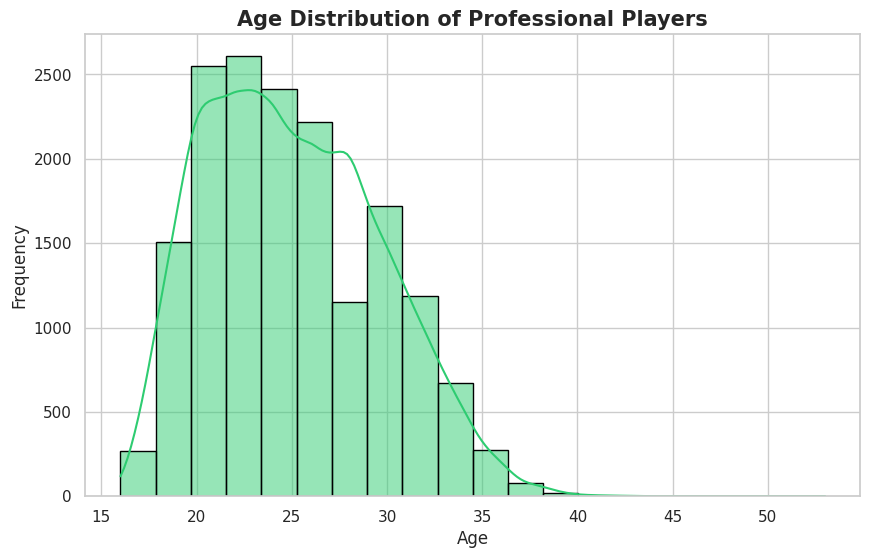

In [ ]:
# Distribution of players ages
plt.figure(figsize=(10, 6))
sns.histplot(df.age, bins=20, kde=True, color='#2ecc71', edgecolor='black')
plt.title('Age Distribution of Professional Players', fontsize=15, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

/tmp/ipykernel_3568/2925559059.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="value_eur",y="short_name",data=topValue,palette='viridis')


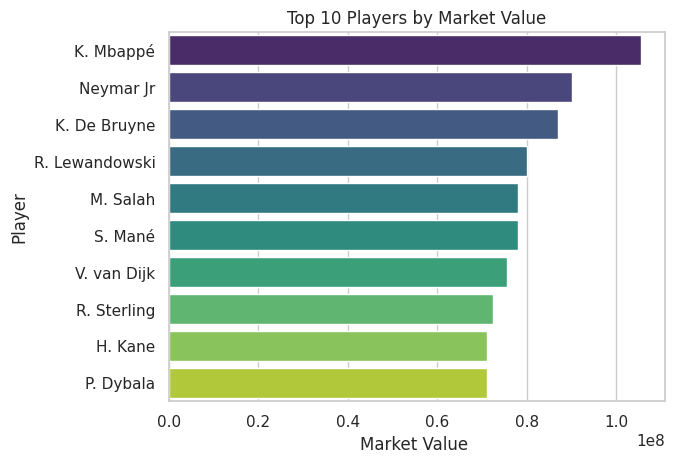

In [ ]:
# Top 10 players by Market Value
sns.barplot(x="value_eur",y="short_name",data=topValue,palette='viridis')
plt.title('Top 10 Players by Market Value')
plt.xlabel("Market Value ")
plt.ylabel("Player")
plt.show()

/tmp/ipykernel_3568/1518894987.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=club_value.values, y=club_value.index, palette='rocket')


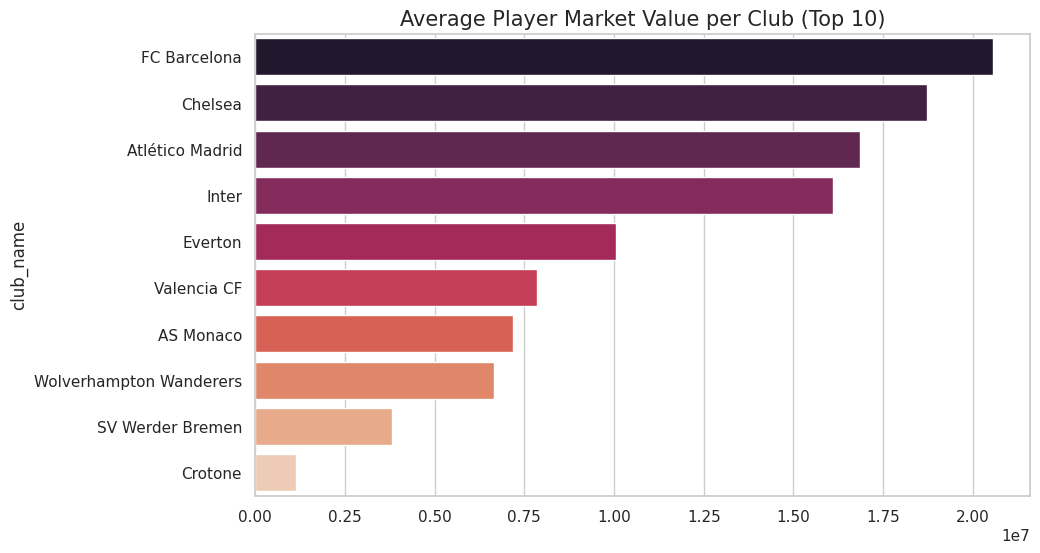

In [ ]:
# Comparing average player prices in the top 10 clubs
top_10_clubs_list = df['club_name'].value_counts().head(10).index
club_value = df[df['club_name'].isin(top_10_clubs_list)].groupby('club_name')['value_eur'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=club_value.values, y=club_value.index, palette='rocket')
plt.title('Average Player Market Value per Club (Top 10)', fontsize=15)
plt.show()

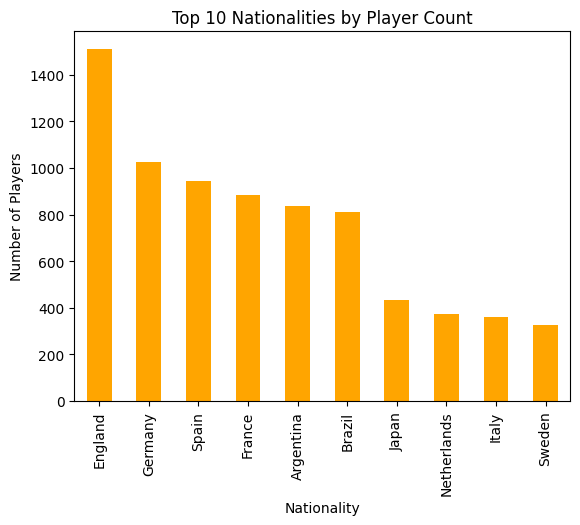

In [ ]:
topnat.plot(kind='bar',color='orange')
plt.title("Top 10 Nationalities by Player Count")
plt.ylabel("Number of Players")
plt.xlabel("Nationality")
plt.show()

/tmp/ipykernel_3568/689311803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='overall', y='short_name', palette='magma')


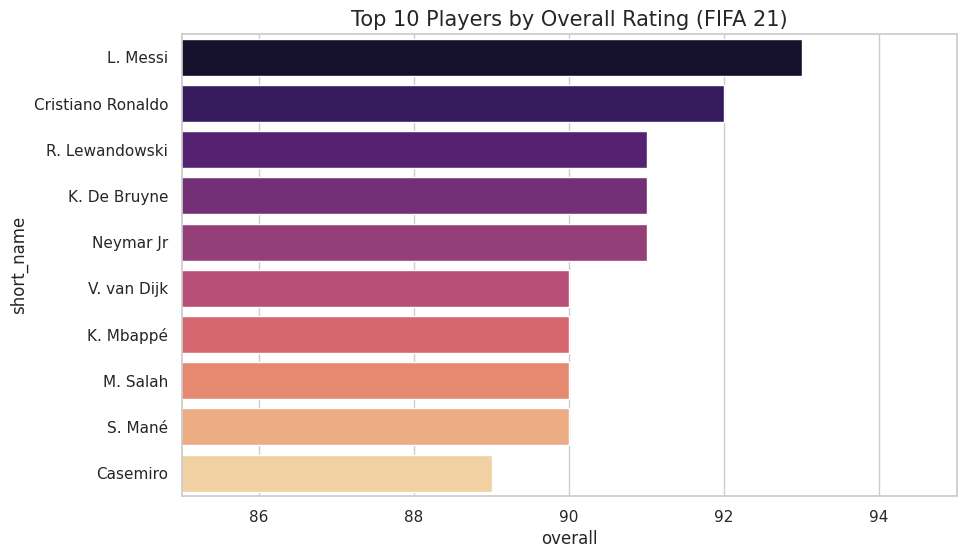

In [ ]:
# Top Players Fifa 21
top_10 = df[['short_name', 'overall']].sort_values('overall', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, x='overall', y='short_name', palette='magma')
plt.title('Top 10 Players by Overall Rating (FIFA 21)', fontsize=15)
plt.xlim(85, 95)
plt.show()

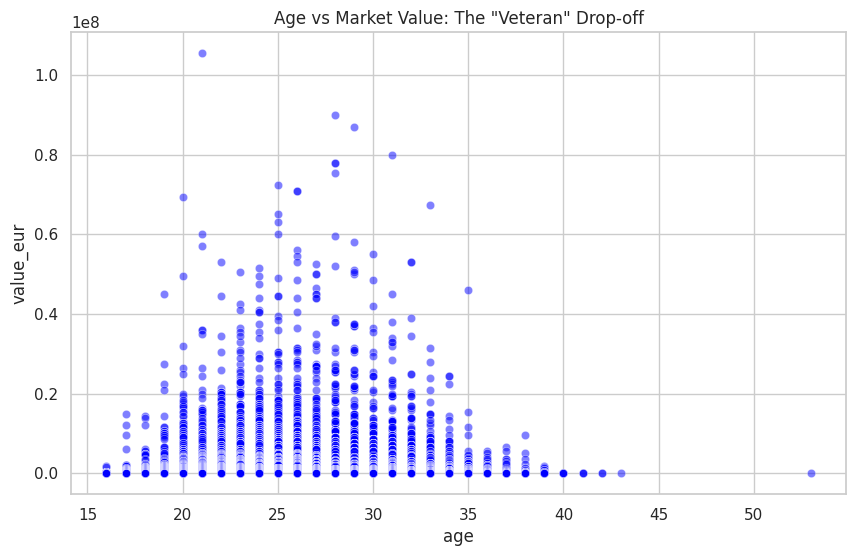

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='value_eur', alpha=0.5, color='blue')
plt.title('Age vs Market Value: The "Veteran" Drop-off')
plt.show()

In [ ]:
df.to_csv("fifa21_cleaned.csv",index=False)

In [ ]:
from google.colab import files
files.download("fifa21_cleaned.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Build and train machine learning and deep learning models to predict football players' market value (value_eur) based on their attributes, and create a comprehensive benchmark comparing Random Forest, XGBoost, CatBoost, and ANN to identify the most accurate architecture.

ML Models

In [ ]:
features = ['age', 'overall', 'potential', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
x = df[features]

In [ ]:
y = df['value_eur']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

In [ ]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

ML - Models

In [ ]:
RF = RandomForestRegressor(random_state=42,n_estimators=500)
RF.fit(x_train_scaled, y_train)
y_pred_RF = RF.predict(x_test_scaled)

In [ ]:
r2_rf = r2_score(y_test, y_pred_RF)
mse_rf = mean_squared_error(y_test, y_pred_RF)
mae_rf = mean_absolute_error(y_test, y_pred_RF)
print('R2 Score for Random Forest:', r2_rf)
print('Mean Squared Error for Random Forest:', mse_rf)
print('Mean Absolute Error for Random Forest:', mae_rf)


R2 Score for Random Forest: 0.9938385742747569
Mean Squared Error for Random Forest: 195821143820.4859
Mean Absolute Error for Random Forest: 78644.92801439713


In [ ]:
cat = CatBoostRegressor(verbose=0, n_estimators=100)
cat.fit(x_train, y_train)
y_pred_cat = cat.predict(x_test)

In [ ]:
r2_cat = r2_score(y_test, y_pred_cat)
mse_cat = mean_squared_error(y_test, y_pred_cat)
mae_cat = mean_absolute_error(y_test, y_pred_cat)
print('R2 Score Cat Boost:', r2_cat)
print('Mean Squared Error for Cat Boost:', mse_cat)
print('Mean Absolute Error for Cat Boost:', mae_cat)

R2 Score Cat Boost: 0.9937689979649819
Mean Squared Error for Cat Boost: 198032403546.80728
Mean Absolute Error for Cat Boost: 107662.97656983115


In [ ]:
xg = XGBRegressor(n_estimators=100, random_state=42)
xg.fit(x_train, y_train)
y_pred_xg = xg.predict(x_test)

In [ ]:
r2_xg = r2_score(y_test, y_pred_xg)
mse_xg = mean_squared_error(y_test, y_pred_xg)
mae_xg = mean_absolute_error(y_test, y_pred_xg)
print('R2 Score XG Boost:', r2_xg)
print('Mean Squared Error for Cat Boost:', mse_xg)
print('Mean Absolute Error for Cat Boost:', mae_xg)

R2 Score XG Boost: 0.9946104288101196
Mean Squared Error for Cat Boost: 171289903104.0
Mean Absolute Error for Cat Boost: 93252.4921875


In [ ]:
gr = GradientBoostingRegressor(n_estimators=100, random_state=42)
gr.fit(x_train, y_train)
y_pred_gr = gr.predict(x_test)

In [ ]:
r2_gr = r2_score(y_test, y_pred_gr)
mse_gr = mean_squared_error(y_test, y_pred_gr)
mae_gr = mean_absolute_error(y_test, y_pred_gr)
print('R2 Score Cat Boost:', r2_gr)
print('Mean Squared Error for Cat Boost:', mse_gr)
print('Mean Absolute Error for Cat Boost:', mae_gr)

R2 Score Cat Boost: 0.9947296540700108
Mean Squared Error for Cat Boost: 167501032125.06198
Mean Absolute Error for Cat Boost: 143962.97339092585


DL - Models

In [ ]:

ann_model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = ann_model.fit(
    x_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)
y_pred_ann = ann_model.predict(x_test_scaled).flatten()
ann_r2 = r2_score(y_test, y_pred_ann)
ann_mae = mean_absolute_error(y_test, y_pred_ann)
print(f"R2 Score_ANN {ann_r2:.4f} {ann_r2*100:.2f}")
print(f"Mean Absolute Error: {ann_mae:,.0f} EUR")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
R2 Score_ANN 0.9026 90.26
Mean Absolute Error: 583,679 EUR


In [ ]:
mse_ann = mean_squared_error(y_test, y_pred_ann)
print('Mean Squared Error for ANN:', mse_ann)

Mean Squared Error for Cat Boost: 3094019309568.0


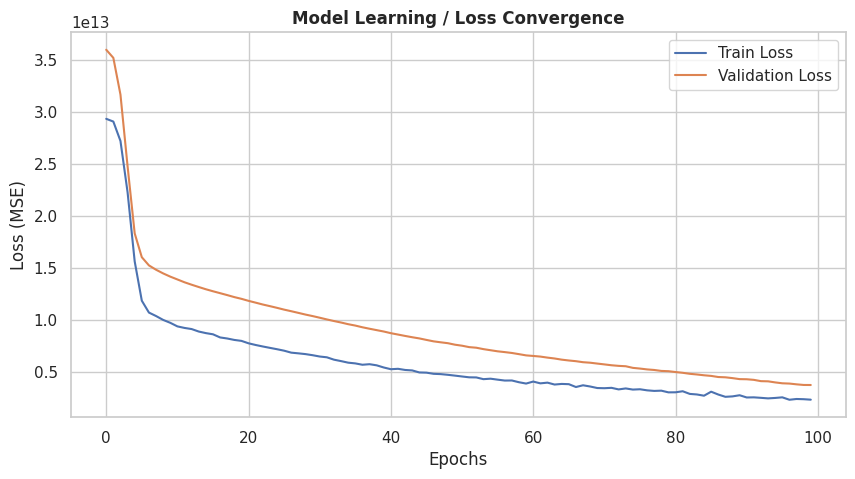

In [ ]:
# Finally, I created a model to see how the template handled each epoch
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Learning / Loss Convergence', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

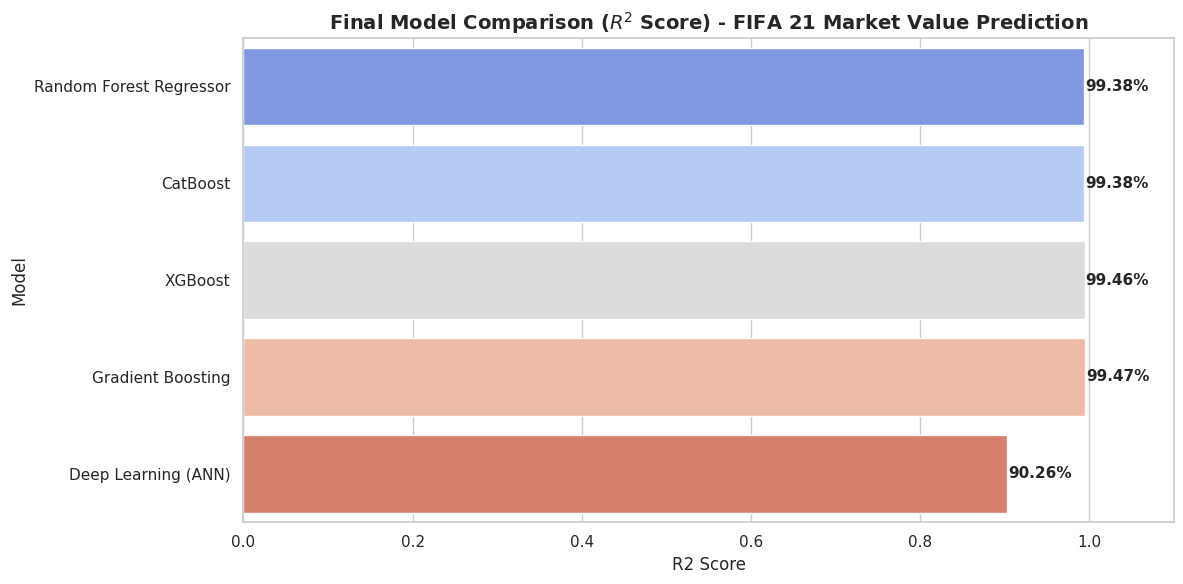

In [ ]:
final_results = [
    {'Model': 'Random Forest Regressor', 'R2 Score': 0.9938385742747569, 'MAE (EUR)': 78644.92801439713},
    {'Model': 'CatBoost', 'R2 Score': 0.9937689979649819, 'MAE (EUR)': 107662.97656983115},
    {'Model': 'XGBoost', 'R2 Score': 0.9946104288101196, 'MAE (EUR)': 93252.4921875},
    {'Model': 'Gradient Boosting', 'R2 Score': 0.9947296540700108, 'MAE (EUR)': 143962.97339092585},
    {'Model': 'Deep Learning (ANN)', 'R2 Score': ann_r2, 'MAE (EUR)': ann_mae}
]

df_final_compare = pd.DataFrame(final_results)
plt.figure(figsize=(12, 6))
sns.barplot(x='R2 Score', y='Model', data=df_final_compare, palette='coolwarm', hue='Model', dodge=False, legend=False)
plt.title('Final Model Comparison ($R^2$ Score) - FIFA 21 Market Value Prediction', fontsize=14, fontweight='bold')
plt.xlim(0, 1.1)
for index, value in enumerate(df_final_compare['R2 Score']):
    plt.text(value + 0.001, index, f'{value:.2%}', va='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()